In [195]:
import os 
import re 
import sys
import argparse
import numpy as np
import pandas as pd
from glob import glob 
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import networkx as nx 
from networkx.drawing.nx_agraph import graphviz_layout
from itertools import combinations

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', 40)
pd.options.display.float_format = '{:.2f}'.format

PATIENT = 'PPCG0086'
INDIR_DPCLUST = '/home/grace/work/PPCG_DifferentialGenesetMutation/data/angel/26.03.2026/ccf/Clonal_trees'
INDIR_TREES = '/home/grace/work/PPCG_DifferentialGenesetMutation/data/angel/06.03.2026/conipher_trees'
INDIR_SCNA = '/home/grace/work/PPCG_DifferentialGenesetMutation/data/angel/26.03.2026/Subclonal_SCNA_with_Avg_CN'
INFILE_SHEET = '/home/grace/work/PPCG_DifferentialGenesetMutation/samplesheet.angel.alldonors.tsv'
INFILE_COSMIC = '/home/grace/work/PPCG_DifferentialGenesetMutation/data/supporting/cosmic/Cosmic_Genes_v103_GRCh37.gencode.genelocations.tsv'
OUTDIR = '/home/grace/work/PPCG_DifferentialGenesetMutation/results/CNA'

CHRSIZES = {
    '1': 249_250_621, '12': 133_851_895,
    '2': 243_199_373, '13': 115_169_878,
    '3': 198_022_430, '14': 107_349_540,
    '4': 191_154_276, '15': 102_531_392,
    '5': 180_915_260, '16': 90_354_753,
    '6': 171_115_067, '17': 81_195_210,
    '7': 159_138_663, '18': 78_077_248,
    '8': 146_364_022, '19': 59_128_983,
    '9': 141_213_431, '20': 63_025_520,
    '10': 135_534_747, '21': 48_129_895,
    '11': 135_006_516, '22': 51_304_566,
    'X': 155_270_560,
}

sheet = pd.read_csv(INFILE_SHEET, sep='\t', header=0)
donors_dpc = set([x.split('/')[-1][:8] for x in glob(f"{INDIR_DPCLUST}/*_Cluster_CCFs.csv")])
donors_tree = set([x.split('/')[-2][:8] for x in glob(f"{INDIR_TREES}/*/allTrees.txt")])
donors_primary = set(sheet[sheet['tissue']=='Primary']['donor'].unique())
ALL_DONORS = sorted(list(donors_dpc & donors_tree))
SAMPLE_2_WGD_LUT = sheet.set_index('sample')['WGD'].to_dict()



In [196]:


def load_battenberg(filepath: str, minspan: int=100) -> pd.DataFrame:
    sample = filepath.split('/')[-1].split('_')[0]
    df = pd.read_csv(filepath, sep='\t', header=0)
    df = df.rename(columns={'startpos': 'start', 'endpos': 'end'})
    df['chr'] = df['chr'].astype(str)
    df['start'] = df['start'].astype(int)
    df['end'] = df['end'].astype(int)
    df = df.dropna(subset=['chr', 'start', 'end', 'nMaj1_A', 'nMin1_A', 'frac1_A'])

    def _get_maxval(row: pd.Series) -> float:
        if row.isna()['frac2_A']:
            assert row['frac1_A'] == 1
            return 1.0
        return max(row['frac1_A'], row['frac2_A'])

    df['chr'] = df['chr'].astype('str')
    df['start'] = df['start'].astype('int')
    df['end'] = df['end'].astype('int')
    df['span'] = df['end'] - df['start']
    df['span'] = df['span'].astype(int)
    df['maxval'] = df.apply(_get_maxval, axis=1)
    df['ccf1_A'] = df['frac1_A'] / df['maxval']
    mask = df['frac2_A'].notna()
    df.loc[mask, 'ccf2_A'] = df.loc[mask, 'frac2_A'] / df.loc[mask, 'maxval']
    df['sample'] = sample
    df = df[['sample', 'chr', 'start', 'end', 'span', 'pval', 'Avg_CN', 'nMaj1_A', 'nMin1_A', 'frac1_A', 'ccf1_A', 'nMaj2_A', 'nMin2_A', 'frac2_A', 'ccf2_A']]
    df = df[df['span']>=minspan].copy()
    return df

def validate_battenberg(df: pd.DataFrame) -> None:
    df = df.sort_values(['chr', 'start'])
    df = df.reset_index(drop=True)
    idx_l = []
    for chrom in df['chr'].unique():
        dfslice = df[df['chr']==chrom]
        if dfslice.shape[0] >= 2:
            for i in range(0, dfslice.shape[0]-1):
                if dfslice.iloc[i]['span'] <= 1:
                    idx_l.append(dfslice.index.to_list()[i])
                elif dfslice.iloc[i]['end'] > dfslice.iloc[i+1]['start']:
                    idx_l.append(dfslice.index.to_list()[i])
    if len(idx_l) > 0:
        for idx in idx_l:
            print()
            print(df.loc[[idx, idx+1]])
        raise NotImplementedError()
    
def filter_segments_minfrac(table: pd.DataFrame, min_frac: float=0.1) -> pd.DataFrame:
    # must be at least 100bp 
    df = table.copy()
    df = df[df['frac']>=min_frac].copy()
    df = df.reset_index(drop=True)
    return df
    
def filter_segments_normal(table: pd.DataFrame) -> pd.DataFrame:
    df = table.copy()
    df = df[df['normal']==False].copy()
    df = df.reset_index(drop=True)
    return df

def _annotate_vtype(row: pd.Series) -> str:
    if row['tcn'] == 0:
        return 'Deep Deletion'
    
    # chrX amps (no chrX shallow dels)
    elif row['chr'] == 'X' and not row['WGD'] and row['tcn'] > 1:
        return 'Amplification'
    elif row['chr'] == 'X' and row['WGD'] == True and row['tcn'] > 2:
        return 'Amplification'
    
    # autosome shallow dels 
    elif row['chr'] != 'X' and row['pattern'] == '1+0':
        return 'Shallow Deletion'
    elif row['chr'] != 'X' and row['WGD'] and row['pattern'] in ['1+0', '2+0', '2+1', '3+0']:
        return 'Shallow Deletion'
    
    # neutral
    elif row['chr'] != 'X' and not row['WGD'] and row['pattern'] == '2+0':
        return 'Neutral'
    elif row['chr'] != 'X' and row['WGD'] and row['pattern'] in ['2+0', '3+1', '4+0']:
        return 'Neutral'
    
    return 'Amplification'

def _annotate_loh(row: pd.Series) -> bool:
    return row['chr'] != 'X' and row['pattern']!='0+0' and row['pattern'].endswith('+0')

def explode_parts(seg: pd.DataFrame, wgd: bool) -> pd.DataFrame:
    # convert battenberg multi-state format to single state 
    lhs = seg.copy()
    rhs = seg[(seg['frac2_A'].notna()) & (seg['frac2_A']!=0)].copy()
    lhs = lhs.rename(columns={'nMaj1_A': 'nMaj', 'nMin1_A': 'nMin', 'frac1_A': 'frac', 'ccf1_A': 'ccf'})
    rhs = rhs.rename(columns={'nMaj2_A': 'nMaj', 'nMin2_A': 'nMin', 'frac2_A': 'frac', 'ccf2_A': 'ccf'})
    df = pd.concat([rhs, lhs], ignore_index=True)

    df['coords'] = df.apply(lambda x: f"chr{x['chr']}:{x['start']}-{x['end']}", axis=1) 
    df['pattern'] = df.apply(lambda x: f"{int(x['nMaj'])}+{int(x['nMin'])}", axis=1)
    df['tcn'] = df['nMaj'] + df['nMin']

    # normal
    NORMAL_STATES_AUTO = ['1+1', '2+2'] if wgd else ['1+1']
    NORMAL_STATES_CHRX = ['1+0', '2+0'] if wgd else ['1+0']
    mask1 = (df['chr']!='X') & (df['pattern'].isin(NORMAL_STATES_AUTO))
    mask2 = (df['chr']=='X') & (df['pattern'].isin(NORMAL_STATES_CHRX))
    df['normal'] = False 
    df.loc[mask1, 'normal'] = True
    df.loc[mask2, 'normal'] = True

    # formatting
    df = df[['sample', 'coords', 'chr', 'span', 'pval', 'pattern', 'normal', 'tcn', 'frac']].copy()
    df = df.sort_values(by=['sample', 'tcn'], ascending=[True, False])
    df['WGD'] = wgd
    return df.copy()

def annotate_alterations(df: pd.DataFrame) -> pd.DataFrame:
    df['vtype'] = df.apply(_annotate_vtype, axis=1)
    df['LOH'] = df.apply(_annotate_loh, axis=1)
    return df 


QUERY = 'PPCG0086e'
filepath = list(glob(f"{INDIR_SCNA}/{QUERY}*.txt"))[0]
wgd = SAMPLE_2_WGD_LUT[QUERY]
df = load_battenberg(filepath, minspan=100)
validate_battenberg(df)
df = explode_parts(df, wgd=wgd)
df = filter_segments_minfrac(df)
df = filter_segments_normal(df)
df = annotate_alterations(df)
print(df['vtype'].value_counts())
df.head()


vtype
Amplification       606
Shallow Deletion     62
Neutral              21
Deep Deletion         7
Name: count, dtype: int64


,sample,coords,chr,span,pval,pattern,normal,tcn,frac,WGD,vtype,LOH
0,PPCG0086e,chr12:120888619-120888762,12,143,1.00,4+3,False,7.00,1.00,False,Amplification,False
1,PPCG0086e,chr14:35561440-35630605,14,69165,1.00,6+1,False,7.00,1.00,False,Amplification,False
2,PPCG0086e,chr5:54804621-55276907,5,472286,0.00,4+2,False,6.00,0.13,False,Amplification,False
3,PPCG0086e,chr8:122009640-122275214,8,265574,0.00,4+2,False,6.00,0.47,False,Amplification,False
4,PPCG0086e,chr20:55647341-55928707,20,281366,0.00,3+3,False,6.00,0.38,False,Amplification,False


variant
LOH              68
amplification    50
deep_deletion     7
Name: count, dtype: int64


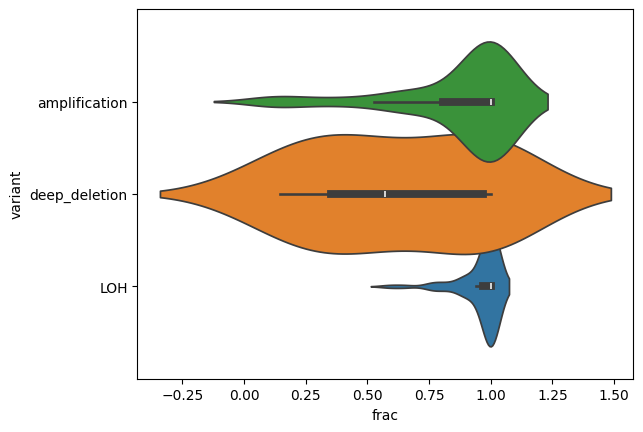

,sample,coords,chr,span,pval,pattern,normal,tcn,frac,WGD,vtype,LOH,variant
76,PPCG0086e,chr10:100040099-100048759,10,8660,0.01,2+0,False,2.00,0.78,False,Neutral,True,LOH
62,PPCG0086e,chr10:100049479-100413929,10,364450,1.00,3+0,False,3.00,1.00,False,Amplification,True,LOH
77,PPCG0086e,chr10:100415065-100583458,10,168393,1.00,2+0,False,2.00,1.00,False,Neutral,True,LOH
107,PPCG0086e,chr10:100634631-101072588,10,437957,0.24,1+0,False,1.00,1.00,False,Shallow Deletion,True,LOH
78,PPCG0086e,chr10:101118520-105175255,10,4056735,1.00,2+0,False,2.00,1.00,False,Neutral,True,LOH


In [197]:
def extract_deepdels(table: pd.DataFrame) -> pd.DataFrame:
    df = table.copy()
    df = df[df['pattern']=='0+0'].copy()
    assert df.shape[0] == df['coords'].nunique()
    return df 

def extract_bigamps(table: pd.DataFrame, wgd: bool) -> pd.DataFrame:
    auto_thresh = 7 if wgd else 5
    chrx_thresh = 4 if wgd else 3

    df = table.copy()
    df = df[df['vtype']=='Amplification'].copy()
    mask1 = (df['chr']!='X') & (df['tcn']>=auto_thresh)
    mask2 = (df['chr']=='X') & (df['tcn']>=chrx_thresh)
    df = df.loc[mask1 | mask2].copy()
    df = df.sort_values('frac', ascending=False)
    df = df.drop_duplicates('coords').copy()
    assert df.shape[0] == df['coords'].nunique()
    return df 

def extract_loh(table: pd.DataFrame) -> pd.DataFrame:
    df = table.copy()
    df = df[df['LOH']==True].copy()
    df = df[df['frac']>0.5].copy()
    assert df.shape[0] == df['coords'].nunique()
    return df

def extract_variant_segments(table: pd.DataFrame, wgd: bool) -> pd.DataFrame:
    df = table.copy()
    
    # identify variant segments 
    deepdels = extract_deepdels(df)
    bigamps = extract_bigamps(df, wgd)
    loh = extract_loh(df)

    # remove LOH segments if also called as other variant types (priority)
    dd_coords = set(deepdels['coords'].unique())
    ba_coords = set(bigamps['coords'].unique())
    assert len(dd_coords & ba_coords) == 0
    loh = loh[~loh['coords'].isin(dd_coords | ba_coords)].copy()

    # combine into single frame 
    deepdels['variant'] = 'deep_deletion'
    bigamps['variant'] = 'amplification'
    loh['variant'] = 'LOH'
    var_df = pd.concat([deepdels, bigamps, loh], ignore_index=True)
    var_df = var_df.sort_values('coords')
    
    # sanity
    assert var_df.shape[0] == var_df['coords'].nunique()
    return var_df

wgd = SAMPLE_2_WGD_LUT[QUERY]
segs = extract_variant_segments(df, wgd)

print(segs['variant'].value_counts())
sns.violinplot(segs, y='variant', x='frac', hue='variant', width=1, gap=-0.3)
ymin = plt.ylim()[1] - 0.5
ymax = plt.ylim()[0] + 0.5
plt.ylim(ymin, ymax)
plt.show()
plt.close()

segs.head()


In [206]:
def load_cosmic(filepath: str) -> pd.DataFrame:
    df = pd.read_csv(filepath, sep='\t', header=0)
    df['chr'] = df['chr'].astype(str)
    df['start'] = df['start'].astype(int)
    df['end'] = df['end'].astype(int)
    df['gene'] = df['gene'].astype(str)
    return df 
    
def extract_variant_genes(cosmic: pd.DataFrame, segs: pd.DataFrame) -> pd.DataFrame:
    THRESH = 0.5
    segs['start'] = segs['coords'].apply(lambda x: int(x.split(':')[1].split('-')[0]))
    segs['end'] = segs['coords'].apply(lambda x: int(x.split('-')[-1]))
    
    data = []
    for _, row in cosmic.iterrows():
        dfslice = segs[(segs['chr']==row['chr']) & (segs['end']>row['start']) & (segs['start']<row['end'])]
        dfslice['start'] = dfslice['start'].clip(lower=row['start'])
        dfslice['end'] = dfslice['end'].clip(upper=row['end'])
        dfslice['span'] = dfslice['end'] - dfslice['start']
        if dfslice.shape[0] > 0:
            for vtype in dfslice['variant'].unique():
                vslice = dfslice[dfslice['variant']==vtype].copy()
                cumspan = vslice['span'].sum()
                genespan = row['end'] - row['start']
                if cumspan > genespan * THRESH:
                    vslice = vslice.sort_values('span', ascending=False)
                    sample = vslice['sample'].values[0]
                    pattern = vslice['pattern'].values[0]
                    var = vslice['variant'].values[0]
                    tcn = vslice['tcn'].values[0]
                    frac = vslice['frac'].values[0]
                    coords = f"chr{row['chr']}:{row['start']}-{row['end']}"
                    gene = row['gene']
                    data.append((coords, '.', pattern, gene, 'CNA', var, frac))
    df = pd.DataFrame.from_records(data, columns=['coords', 'ref', 'alt', 'gene', 'vtype', 'annotation', 'est_ccf'])
    return df 

cosmic = load_cosmic(INFILE_COSMIC)
genes = extract_variant_genes(cosmic, segs)
assert genes['gene'].nunique() == genes.shape[0]
print(genes.groupby('annotation')['gene'].nunique())
genes.head()

annotation
LOH              29
amplification     9
deep_deletion     1
Name: gene, dtype: int64


,coords,ref,alt,gene,vtype,annotation,est_ccf
0,chr1:11166592-11322564,.,1+0,MTOR,CNA,LOH,0.82
1,chr1:47681962-47697892,.,1+0,TAL1,CNA,LOH,0.83
2,chr1:47715811-47779819,.,1+0,STIL,CNA,LOH,0.83
3,chr1:154127780-154167124,.,4+1,TPM3,CNA,amplification,1.00
4,chr5:55230923-55290850,.,4+1,IL6ST,CNA,amplification,0.87
